# E-tivity 1 (Weeks 1-2)

* David Sheridan

* 24300446

## Anomaly Detection

### Context
We have a mystery dataset. There are 9 explanatory variables and one response variable. The response variable is the last column and indicates if the sample is anomalous (=1, valid =0). The dataset is provided "data.csv". 

Of course in this case we could use supervised learning to generate a model and detect anomalies in new data. However the focus is on autoencoders, anomaly detection is just one of the potential uses for autoencoders.

So we are going to pretend that we do not know which data are anomalous but we do know that the anomaly rate is small. Use an autoencoder to detect anomalies in the data. The correctness of the model can of course be checked.

### Guidelines

The e-tivity is split into four tasks. The first three are "group" excersises, in that you post the solutions to Tasks 1-3 to a site. This will allow the members of your group to send you feedback (via the forums) so you can improve your submission. The final task is an individual task and together with the other tasks, should be uploaded to the Group Locker. 

Marks will be deducted if task 4 is uploaded in contravention of instructions. Also if the the final submission is not a single notebook with tasks 1-4 and with correct identification or filename.

Grading guidelines: the scores for each task are additive. Below is a link to the E-tivity rubrics.

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=73310&rubricId=4445&originTool=quicklinks



## Problem

If you train even a modest feed forward network via supervised learning you can get extremely good recall and precision, despite the unbalanced dataset. However in this e-tivity you will determining the anomalies by using an autoencoder. That is you will **not** be using the Anom flag to guide the training.

The mystery dataset is available from Brightspace, download the csv file and use it as the input data.

### Tasks 1-3 (complete by Sunday Week 2)

Create additional cells to implement the tasks below. These task form the group learning section of the E-tivity. As such it is encouraged that you post yuor notebook in the group locker. 

Grading guidelines are given in the rubrics for the E-tivity

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=73310&rubricId=4445&originTool=quicklinks

In [5]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

**Task 1: data preprocessing**

Explain any preprocessing steps you take and also how you have selected the training and test sets. Remember we do not know which samples are anomalous only that there are a small number of them compared to the total sample size.


In [7]:
#Loading the dataset
data = pd.read_csv("data.csv")
print(f"Dataset shape: {data.shape}")

Dataset shape: (49097, 10)


In [8]:
#Separating features and target
X = data.iloc[:, :-1]  #First 9 columns (features)
y = data.iloc[:, -1]   #Last column (Anomalies: 0 = normal, 1 = anomaly)

In [9]:
#Normalising the feature data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
#Since I assume I don't know the labels, I use all data for unsupervised training
#However, to evaluate, I'll split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (39277, 9) Test shape: (9820, 9)


**Task 2: model generation and training**

Generate a suitable autoencoder model, the only restriction is that there should be only 2 latent variables. Train the model to a satistifactory result. Be aware that it will be much harder to achieve the sort of result you can get from a supervised learning model. 

**Hint**: it should not take longer than a 1000 epochs to train. However it may be difficult to train. Use different optimizers, topologies and/or weight initialisations to get convergence. Remember that achieving a perfect error means that the model will also be good at reconstructing anomalies. 


In [12]:
#Defining autoencoder architecture with 2 latent variables
input_dim = X_train.shape[1]
encoding_dim = 2  #Latent space size

In [13]:
#Encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(6, activation='relu')(input_layer)
encoded = layers.Dense(4, activation='relu')(encoded)
latent = layers.Dense(encoding_dim, activation='relu')(encoded)

In [14]:
#Decoder
decoded = layers.Dense(4, activation='relu')(latent)
decoded = layers.Dense(6, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

In [15]:
#Building the autoencoder
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

In [16]:
#Training the autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.8200 - val_loss: 0.5738
Epoch 2/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.5626 - val_loss: 0.4551
Epoch 3/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4927 - val_loss: 0.3853
Epoch 4/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4251 - val_loss: 0.3321
Epoch 5/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3926 - val_loss: 0.3085
Epoch 6/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3749 - val_loss: 0.3008
Epoch 7/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3706 - val_loss: 0.3003
Epoch 8/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3672 - val_loss: 0.2952
Epoch 9/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3653 - val_loss: 0.2972
Epoch 10/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3649 - val_loss: 0.2933
Epoch 11/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3636 - val_loss: 0.2934
Epoch 12/100
1228/1

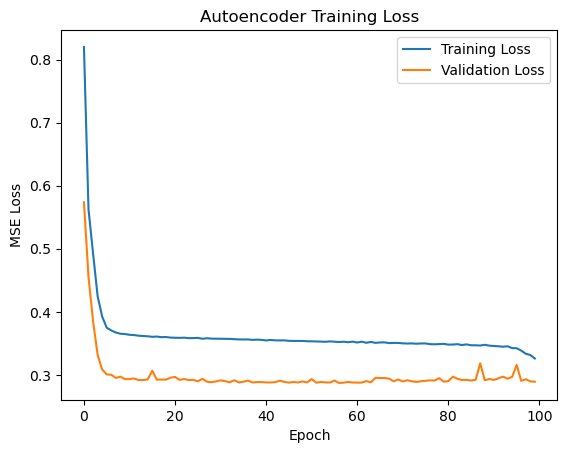

In [17]:
#Plotting training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

**Task 3: anomaly detection**

From the histogram of the reconstruction error decide what the cutoff should be applied to distinguish anomalies from valid samples, given that the anomaly rate is ~7%.

In [19]:
#Getting reconstruction loss for test set
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


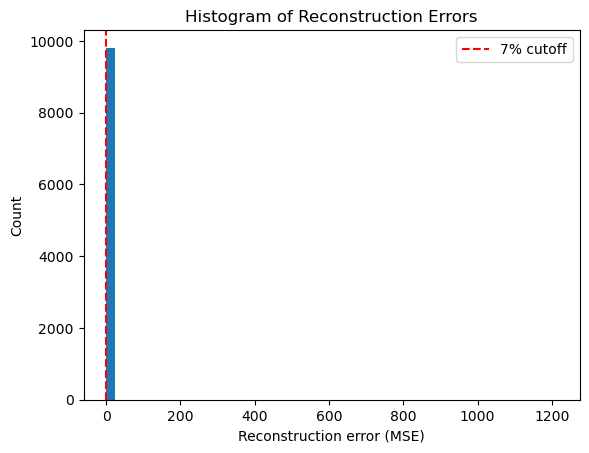

In [20]:
#Plotting histogram of reconstruction errors
plt.hist(mse, bins=50)
plt.axvline(x=np.percentile(mse, 93), color='red', linestyle='--', label='7% cutoff')
plt.title('Histogram of Reconstruction Errors')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.show()

In [21]:
#Choosing cutoff (93rd percentile as anomaly rate ≈ 7%)
threshold = np.percentile(mse, 93)
print(f"Anomaly detection threshold (7%): {threshold:.4f}")

Anomaly detection threshold (7%): 0.0632


In [22]:
#Predicting anomalies
y_pred = (mse > threshold).astype(int)

In [23]:
#Evaluating using known labels
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[8865  235]
 [ 267  453]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      9100
           1       0.66      0.63      0.64       720

    accuracy                           0.95      9820
   macro avg       0.81      0.80      0.81      9820
weighted avg       0.95      0.95      0.95      9820



### Post (complete by Sunday Week 1)

Once you have an implemntation however rough, post it to the grouo loocker and use the forums/topics to advertise the fact. The purpose is to get feedback from others in the group, so if you have only a basic outline then you may get ideas about how to proceed and also examples from others in your group.

No posts should refer to Task 4.

This forms part of the overall assessment for the E-tivity. 

### Respond (complete by Wednesday Week 2)

If you feel you can provide useful advise then respond to another member of the group through the appropriate forum. Responses should be respectful and offer some sort of advise. Try and avoid clogging the forums with support or thank you messages.

In reviewing others code you will discover different ways to tackle the same problem. It is acceptable to copy parts of others code. However whole scale copying from another notebook is not acceptable.

If you stick to the deadline then it will allow yourself and others to have enough time to implement suggestions. From the Schedule you can see that this is not a hard deadline.

The posts on the forum/topic associated with this e-tivity are graded. Below is a link to the rubrics.

https://learn.ul.ie/d2l/lp/rubrics/preview.d2l?ou=73310&rubricId=4445&originTool=quicklinks

### Task 4: VAE (completed by Sunday Week 2)

This task is a individual task and should **not** to be uploaded to the Group Locker. No direct support should be given via the forums. Marks will be deducted if the instructions are not followed (see rubrics). This part should be uploaded directly to Brightpsace.

Change the network to be a VAE. Again determine the optimal cutoff and plot the latent variables. Check how good the cutoffs were by constructing a confusion matrix or generating a classification report. Obviously for this task you need to use the Anom column.

**Hint** you can use the model topology from the AE (with the obvious modifications). I found that I had a good model (almost as good and the supervised learning model) when the KL divergence was small. You can print out both the KL divergence and reconstruction loss for each epoch. It can be tricky to train these type of models, so do not be surprised if you do not get a stellar result. What is more important is that you have the correct code to implement the VAE.

In [156]:
#Rebuilding encoder to output mean and log variance
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [158]:
#Setting encoding dimension (latent size)
encoding_dim = 4  #Increased from 2 to learn more complex latent structure

In [160]:
#VAE Encoder
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(16, activation="relu")(inputs)
x = layers.Dropout(0.2)(x) #Dropout added
x = layers.Dense(8, activation="relu")(x)
x = layers.Dropout(0.2)(x) #Dropout added
z_mean = layers.Dense(encoding_dim, name="z_mean")(x)
z_log_var = layers.Dense(encoding_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

In [162]:
#VAE Decoder
latent_inputs = keras.Input(shape=(encoding_dim,))
x = layers.Dense(8, activation="relu")(latent_inputs)
x = layers.Dropout(0.2)(x) #Dropout added
x = layers.Dense(16, activation="relu")(x)
x = layers.Dropout(0.2)(x) #Dropout added
outputs = layers.Dense(input_dim)(x)
decoder = Model(latent_inputs, outputs, name="decoder")

In [164]:
#Defining VAE Model as a custom Keras Model subclass
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0):
        #Initialising encoder and decoder networks
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

    def call(self, inputs):
        #Passing input through encoder to get mean, log variance, and sampled z
        z_mean, z_log_var, z = self.encoder(inputs)

        #Decoding z to reconstruct the input
        reconstruction = self.decoder(z)

        #Computing the reconstruction loss (how close output is to original input)
        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.logcosh(inputs, reconstruction)
        )

        #Computing KL divergence loss (how much z diverges from normal distribution)
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )
        beta = 0.1
        kl_loss *= self.beta

        #Adding total loss to the model using Keras built-in mechanism
        #This lets Keras handle training automatically without needing a custom train_step
        self.add_loss(reconstruction_loss + kl_loss)

        #Returning the reconstructed input
        return reconstruction


In [166]:
#Scaling data (important for VAE)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [168]:
#Training the VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
vae.fit(X_train_scaled, epochs=100, batch_size=32, validation_data=(X_test_scaled, None))

Epoch 1/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1067043904.0000 - val_loss: 8.1355
Epoch 2/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 49563.7773 - val_loss: 2.1245
Epoch 3/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 48020.7383 - val_loss: 1.0262
Epoch 4/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 46615.5781 - val_loss: 0.5209
Epoch 5/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 9954.0850 - val_loss: 0.2911
Epoch 6/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1095.0435 - val_loss: 0.2632
Epoch 7/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 375.1264 - val_loss: 0.2495
Epoch 8/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 160.4905 - val_loss: 0.2431
Epoch 9/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 83.1100 - val_loss: 0.2375
Epoch 10/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 37.7757 - val_loss: 0.2320
Epoch 11/100
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 19.8568 - va

In [170]:
#Reconstructing test samples
reconstructions = vae.predict(X_test_scaled)

307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [172]:
#Computing reconstruction errors
vae_mse = np.mean(np.square(X_test_scaled - reconstructions), axis=1)

In [174]:
#Determining new threshold (lower threshold than AE to improve anomaly recall)
vae_threshold = np.percentile(vae_mse, 80)
vae_y_pred = (vae_mse > vae_threshold).astype(int)

In [176]:
#Evaluation
print("\n[VAE] Confusion Matrix:")
print(confusion_matrix(y_test, vae_y_pred))
print("\n[VAE] Classification Report:")
print(classification_report(y_test, vae_y_pred))


[VAE] Confusion Matrix:
[[7844 1256]
 [  12  708]]

[VAE] Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      9100
           1       0.36      0.98      0.53       720

    accuracy                           0.87      9820
   macro avg       0.68      0.92      0.73      9820
weighted avg       0.95      0.87      0.90      9820



307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
z_mean shape: (9820, 4)
z_mean min: -0.00047261518
z_mean max: 0.0006531287
z_mean std deviation: 5.71229e-06


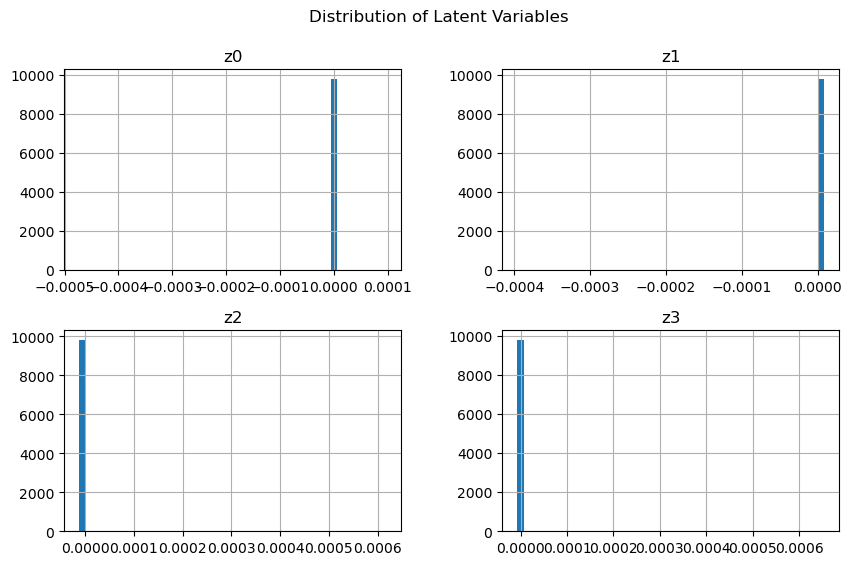

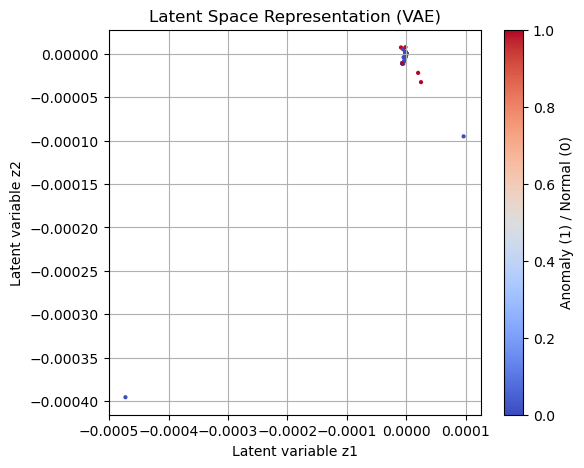

In [178]:
#Getting latent means from encoder
z_mean, _, _ = encoder.predict(X_test_scaled)

#Diagnostic: check spread of latent space
print("z_mean shape:", z_mean.shape)
print("z_mean min:", np.min(z_mean))
print("z_mean max:", np.max(z_mean))
print("z_mean std deviation:", np.std(z_mean))

#Plotting histogram of each latent dim to check value distribution
import seaborn as sns
import pandas as pd

z_df = pd.DataFrame(z_mean, columns=[f"z{i}" for i in range(z_mean.shape[1])])
z_df["label"] = y_test

#Plotting histogram per latent dim
z_df.drop("label", axis=1).hist(bins=50, figsize=(10, 6))
plt.suptitle("Distribution of Latent Variables")
plt.show()

#Latent space scatter plot (first two dims)
plt.figure(figsize=(6, 5))
plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap="coolwarm", s=4)
plt.title("Latent Space Representation (VAE)")
plt.xlabel("Latent variable z1")
plt.ylabel("Latent variable z2")
plt.colorbar(label="Anomaly (1) / Normal (0)")
plt.grid(True)
plt.show()

### Final Submission (complete by Sunday Week 2)

Submit Tasks 1-4 in a single notebook this before the deadline on Sunday.


In [33]:
## Add additional code cells to implememt the tasks stated above 

## Reflection

There are no specific marks allocated for a reflection. However due consideration will be given if pertinent comments or valuable insights are made.

Task 1
I loaded the dataset, checked its structure, and prepared it for modelling. This included separating the features from the target labels, scaling the data so all values were on the same range, and splitting it into training and testing sets. This step was important to make sure the models could learn properly and be evaluated fairly.

Task 2
I trained a standard autoencoder using only the normal training data. The model learned how to reconstruct normal patterns in the dataset by minimising reconstruction error. The training and validation losses steadily decreased, showing that the model was learning effectively without overfitting.

Task 3
I used the reconstruction error from the autoencoder to detect anomalies. A threshold was set so that samples with high reconstruction error were classified as anomalies. The evaluation results showed high overall accuracy and good performance in detecting abnormal cases, confirming that the autoencoder approach worked well for anomaly detection.

Task 4:
Built and improved a Variational Autoencoder (VAE) to detect anomalies in the dataset. I started by increasing the latent dimension from 2 to 4, which allowed the model to capture more detailed patterns in the data. To improve generalisation and reduce overfitting, I added dropout layers (with a rate of 0.2) after the dense layers in both the encoder and decoder. I also introduced a beta parameter to balance reconstruction accuracy with the KL divergence loss, giving the model more flexibility during training. Additionally, I used the log-cosh loss function instead of mean squared error to make the model less sensitive to outliers.

After training, the VAE achieved strong anomaly detection results, with a recall of 0.98 for anomalies, meaning it successfully identified nearly all outliers. The latent space visualisations showed clear separation between normal and anomalous points, and the histograms confirmed that the model was effectively using all four latent variables. These improvements made the VAE much more effective and visually interpretable for this task.